# EDA - Chunks from `pdf_section_chunker/chunks`

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_rows", 50)

## 1. Load chunks into a DataFrame

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "EDA" else Path.cwd()
CHUNKS_DIR = PROJECT_ROOT / "pdf_section_chunker" / "chunks"
print(f"Reading from: {CHUNKS_DIR}")
assert CHUNKS_DIR.exists(), f"Chunks dir not found: {CHUNKS_DIR}"

records = []
for paper_dir in sorted(CHUNKS_DIR.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else 0):
    if not paper_dir.is_dir():
        continue
    paper_id = int(paper_dir.name)
    chunk_files = sorted(paper_dir.glob("*.md"), key=lambda f: int(f.stem.split("-")[0]))
    for chunk_file in chunk_files:
        text = chunk_file.read_text(encoding="utf-8")
        stem = chunk_file.stem
        prefix, _, section = stem.partition("-")
        section_raw = section if section else stem
        section_normalized = re.sub(r"^[\d._\s]+", "", section_raw).lower()
        records.append({
            "paper_id": paper_id,
            "chunk_index": int(prefix) if prefix.isdigit() else None,
            "section_raw": section_raw,
            "section_normalized": section_normalized,
            "word_count": len(text.split()),
            "char_count": len(text),
            "line_count": text.count("\n") + 1,
            "file_path": str(chunk_file.relative_to(PROJECT_ROOT)),
        })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} chunks across {df['paper_id'].nunique()} papers")
df.head()

Reading from: c:\Users\chapp\Desktop\Graph-Rag-hashimotos-thyroiditis\pdf_section_chunker\chunks
Loaded 857 chunks across 115 papers


,paper_id,chunk_index,section_raw,section_normalized,word_count,char_count,line_count,file_path
0,1,1,abstract,abstract,330,2160,6,pdf_section_chunker\chunks\1\1-abstract.md
1,1,2,1._introduction,introduction,461,3222,13,pdf_section_chunker\chunks\1\2-1._introduction.md
2,1,3,2._materials_and_methods,materials_and_methods,1100,7700,24,pdf_section_chunker\chunks\1\3-2._materials_an...
3,1,4,3._results,results,2324,12518,163,pdf_section_chunker\chunks\1\4-3._results.md
4,1,5,4._discussion,discussion,1604,10805,22,pdf_section_chunker\chunks\1\5-4._discussion.md


## 2. Overall stats

In [3]:
print(f"Total papers: {df['paper_id'].nunique()}")
print(f"Total chunks: {len(df)}")
print(f"Total words: {df['word_count'].sum():,}")
print(f"Total chars: {df['char_count'].sum():,}")
print()
print("Word count summary:")
print(df["word_count"].describe().to_string())

Total papers: 115
Total chunks: 857
Total words: 708,955
Total chars: 4,902,645

Word count summary:
count      857.000000
mean       827.252042
std       1014.130389
min         19.000000
25%        244.000000
50%        529.000000
75%       1033.000000
max      10573.000000


## 3. Sections per paper

In [5]:
sections_per_paper = df.groupby("paper_id").size().sort_values(ascending=False)

print("Sections per paper - describe:")
print(sections_per_paper.describe().to_string())
print()
print("Top 10 papers with most sections:")
print(sections_per_paper.head(10).to_string())
print()
print("Bottom 10 papers with fewest sections:")
print(sections_per_paper.tail(10).to_string())

Sections per paper - describe:
count    115.000000
mean       7.452174
std        2.646558
min        1.000000
25%        6.000000
50%        7.000000
75%        8.000000
max       22.000000

Top 10 papers with most sections:
paper_id
6      22
110    17
14     16
60     16
67     12
59     12
84     12
89     12
23     11
36     11

Bottom 10 papers with fewest sections:
paper_id
97     6
7      5
111    5
17     5
65     5
95     5
88     4
73     4
12     1
83     1


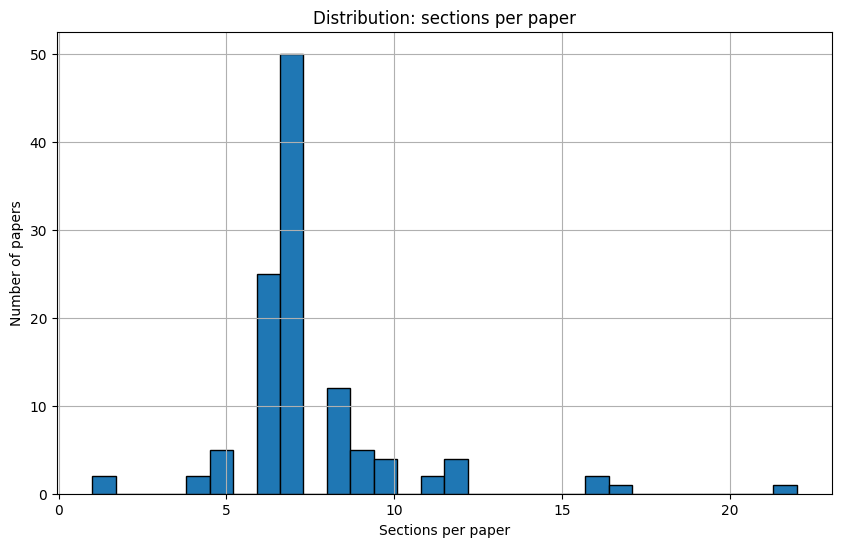

In [6]:
fig, ax = plt.subplots()
sections_per_paper.plot.hist(bins=30, ax=ax, edgecolor="black")
ax.set_xlabel("Sections per paper")
ax.set_ylabel("Number of papers")
ax.set_title("Distribution: sections per paper")
plt.show()

## 4. Word count distribution

In [7]:
percentiles = [25, 50, 75, 90, 95, 99]
print("Chunk word count percentiles:")
for p in percentiles:
    val = int(np.percentile(df["word_count"], p))
    print(f"  p{p:>2}: {val:>6,} words")

Chunk word count percentiles:
  p25:    244 words
  p50:    529 words
  p75:  1,033 words
  p90:  1,785 words
  p95:  2,473 words
  p99:  5,372 words


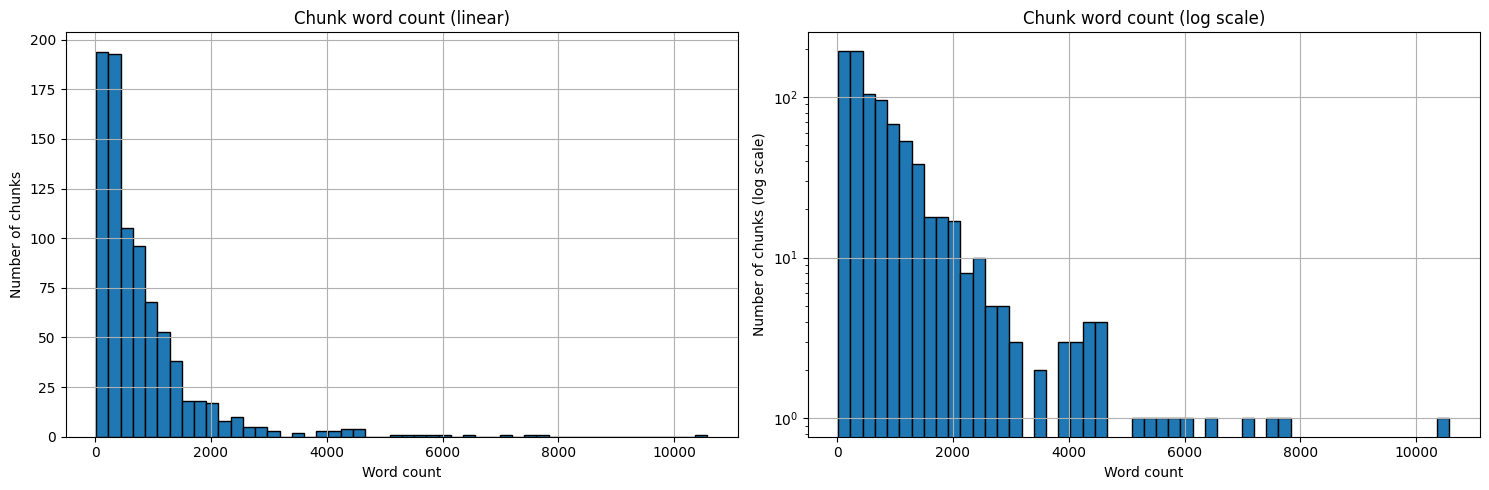

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df["word_count"], bins=50, edgecolor="black")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of chunks")
axes[0].set_title("Chunk word count (linear)")

axes[1].hist(df["word_count"], bins=50, edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of chunks (log scale)")
axes[1].set_title("Chunk word count (log scale)")
plt.tight_layout()
plt.show()

## 5. Long sections - informs sub-chunking threshold

How many chunks exceed each candidate threshold? What share of total words do they account for?

In [9]:
thresholds = [800, 1000, 1500, 2000, 2500, 3000]
total_chunks = len(df)
total_words = df["word_count"].sum()

print(f"{'Threshold':>10} {'Chunks':>8} {'% chunks':>10} {'Words':>12} {'% words':>10}")
print("-" * 56)
for t in thresholds:
    long_df = df[df["word_count"] > t]
    pct_chunks = len(long_df) / total_chunks * 100
    long_words = long_df["word_count"].sum()
    pct_words = long_words / total_words * 100
    print(f"{t:>10} {len(long_df):>8} {pct_chunks:>9.1f}% {long_words:>12,} {pct_words:>9.1f}%")

 Threshold   Chunks   % chunks        Words    % words
--------------------------------------------------------
       800      297      34.7%      514,054      72.5%
      1000      226      26.4%      450,677      63.6%
      1500      110      12.8%      309,649      43.7%
      2000       68       7.9%      236,245      33.3%
      2500       42       4.9%      178,940      25.2%
      3000       29       3.4%      143,845      20.3%


In [10]:
print("Top 20 longest chunks:")
df.sort_values("word_count", ascending=False).head(20)[
    ["paper_id", "section_raw", "word_count", "char_count"]
]

Top 20 longest chunks:


,paper_id,section_raw,word_count,char_count
580,77,references,10573,74794
167,22,4._genetic_factors_and_autoimmune_thyroid_dise...,7801,53252
51,6,references,7555,57845
169,22,references,7131,51671
575,77,4._genetic_factors,6443,41649
777,105,references,5955,46095
475,63,references,5909,41958
473,63,4._discussion,5674,36397
408,56,3._results,5471,38394
562,75,references,5295,37422


## 6. Section name frequency

In [11]:
section_counts = df["section_normalized"].value_counts()
print(f"Distinct normalized section names: {len(section_counts)}")
print()
print("Top 25 most common:")
print(section_counts.head(25).to_string())

Distinct normalized section names: 219

Top 25 most common:
section_normalized
references                112
abstract                  108
introduction              105
discussion                 82
results                    61
conclusions                40
conclusion                 34
materials_and_methods      32
methods                    26
appendix_a                  8
case_report                 6
case_presentation           6
result                      4
material_and_methods        4
treatment                   4
subjects_and_methods        3
summary                     3
diagnosis                   3
epidemiology                3
practice_points             3
research_agenda             3
genetic_susceptibility      2
thyroid_autoantibodies      2
background                  2
methods_and_materials       2


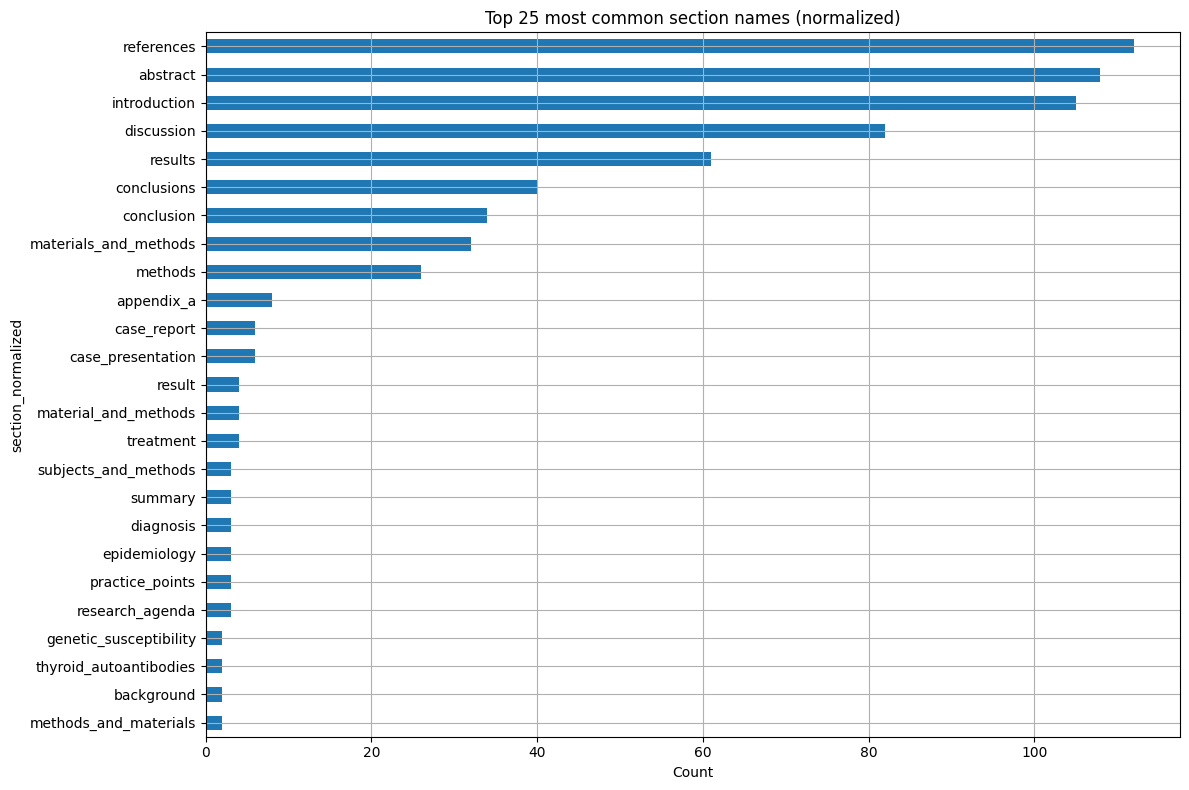

In [12]:
fig, ax = plt.subplots(figsize=(12, 8))
section_counts.head(25).plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Top 25 most common section names (normalized)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Outliers / missing data

In [13]:
short = df[df["word_count"] < 30].sort_values("word_count")
print(f"Chunks with < 30 words (likely stubs): {len(short)}")
if len(short):
    print(short[["paper_id", "section_raw", "word_count"]].to_string(index=False))

Chunks with < 30 words (likely stubs): 7
 paper_id                         section_raw  word_count
        5                          appendix_a          19
       19                          appendix_a          19
       32                          appendix_a          19
       48                          appendix_a          23
      107                          appendix_a          23
       78                          appendix_a          23
        6 14._useful_links_and_support_groups          29


In [14]:
long = df[df["word_count"] > 2500].sort_values("word_count", ascending=False)
print(f"Chunks with > 2500 words (very long): {len(long)}")
if len(long):
    print(long[["paper_id", "section_raw", "word_count"]].to_string(index=False))

Chunks with > 2500 words (very long): 42
 paper_id                                                                                                    section_raw  word_count
       77                                                                                                     references       10573
       22                                                             4._genetic_factors_and_autoimmune_thyroid_diseases        7801
        6                                                                                                     references        7555
       22                                                                                                     references        7131
       77                                                                                             4._genetic_factors        6443
      105                                                                                                     references        5955
       63                   

In [15]:
one_section = sections_per_paper[sections_per_paper == 1]
print(f"Papers with only 1 section: {len(one_section)}")
if len(one_section):
    print(one_section.to_string())

Papers with only 1 section: 2
paper_id
12    1
83    1
